In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from modules.MyQComponent import *
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, open_docs
from qiskit_metal.qlibrary.terminations.launchpad_wb_driven import LaunchpadWirebondDriven

import matplotlib.pyplot as plt
import numpy as np

# Analysis
# from qiskit_metal.renderers.renderer_gds.gds_renderer import QGDSRenderer
# from qiskit_metal.analyses.quantization import EPRanalysis
from qiskit_metal.analyses.quantization import EPRanalysis
from qiskit_metal.analyses.simulation import ScatteringImpedanceSim
from qiskit_metal.analyses.sweep_and_optimize.sweeping import Sweeping
import pyEPR as epr

In [3]:
filelist = ["chipdesign"] #"TcSampleDesign", "chipdesign"

design = designs.DesignPlanar()
design._chips['main']['size']['size_x'] = '9mm'
design._chips['main']['size']['size_y'] = '9mm'
gui = MetalGUI(design)
design.overwrite_enabled = True
hfss = design.renderers.hfss

In [4]:
# Define for renderer
eig_qres = EPRanalysis(design, "hfss")
hfss = design.renderers.hfss
hfss = eig_qres.sim.renderer
q3d = design.renderers.q3d

In [5]:
component_list = MyQComponents(design, filelist)

# Driven Lauchpad 1
# x = '-1.5mm'
# y = '2.0mm'
# launch_options = dict(chip='main', pos_x=x, pos_y=y, orientation='360', lead_length='30um')
# LP1 = LaunchpadWirebondDriven(design, 'LP1', options = launch_options)
# design.components.LP1.pins.keys()

gui.rebuild()  # rebuild the design and plot

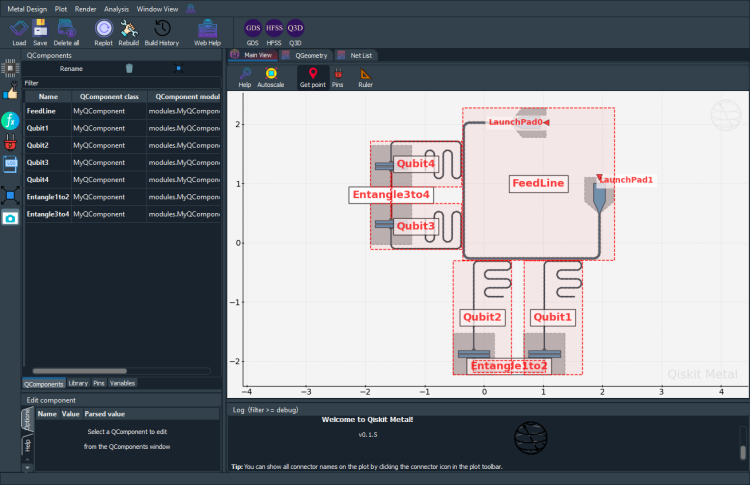

In [6]:
gui.rebuild()
#gui.autoscale()
#gui.edit_component(component)
gui.zoom_on_components(component_list)
gui.highlight_components(component_list)
gui.screenshot()

## Eigen mode

In [7]:
eig_qres.sim.setup_update(max_delta_f = 0.4, min_freq_ghz = 1.1)


In [8]:
eig_qres.sim.run(name="Qbit", components=component_list, open_terminations=[], box_plus_buffer = False)

INFO 08:50AM [connect_project]: Connecting to Ansys Desktop API...
INFO 08:50AM [load_ansys_project]: 	Opened Ansys App
INFO 08:50AM [load_ansys_project]: 	Opened Ansys Desktop v2023.2.0
INFO 08:50AM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/HFSS/ymino/
	Project:   Project15
INFO 08:50AM [connect_design]: No active design found (or error getting active design).
INFO 08:50AM [connect]: 	 Connected to project "Project15". No design detected
INFO 08:50AM [connect_design]: 	Opened active design
	Design:    Qbit_hfss [Solution type: Eigenmode]
WARNING 08:50AM [connect_setup]: 	No design setup detected.
WARNING 08:50AM [connect_setup]: 	Creating eigenmode default setup.
INFO 08:50AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 08:54AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 08:54AM [analyze]: Analyzing setup Setup


com_error: (-2147352567, 'Exception occurred.', (0, None, None, None, 0, -2147024349), None)

## Driven Modal

In [ ]:
from qiskit_metal.analyses.simulation import ScatteringImpedanceSim
em1 = ScatteringImpedanceSim(design, "hfss")

In [ ]:
design_name= "Sweep_DrivenModal"
qcomp_render = [] # Means to render everything in qgeometry table.
open_terminations = []

# Here, pin LP1_in and LP2_in are converted into lumped ports,
#           each with an impedance of 50 Ohms. <br>
port_list = [('FeedLine', 'LaunchPad0', 50),
             ('FeedLine', 'LaunchPad1', 50)]
#port_list = []
box_plus_buffer = True

In [ ]:
# we use HFSS as rendere
hfss = em1.renderer
hfss.start()

In [ ]:
# Here we activate the design for a drivenmodal solution
hfss.activate_ansys_design("HangingResonator", 'hfss hybrid modal network')
setup_args = Dict(max_delta_s=0.001)
setup_args.name = 'Setup'
hfss.edit_drivenmodal_setup(setup_args)

In [ ]:
# set buffer
hfss.options['x_buffer_width_mm'] = 0.1
hfss.options['y_buffer_width_mm'] = 0.1

In [ ]:
# clean the design if needed
hfss.clean_active_design()

In [ ]:
# render the design
hfss.render_design(selection=[], 
                   open_pins=open_terminations, 
                   port_list=port_list, 
                   box_plus_buffer = box_plus_buffer)

In [ ]:
# for acurate simulations, make sure the mesh is fine enough for the meander
hfss.modeler.mesh_length(
                'fine_mesh',
                ['launch_pad_0_test'],
                MaxLength='0.01mm')

In [ ]:
hfss.add_sweep(setup_name="Setup", 
               name="Sweep", 
               start_ghz=4.0,
               stop_ghz=10.0,
               count=601,
               type="Interpolating")

In [ ]:
hfss.analyze_sweep('Sweep', 'Setup')

In [ ]:
%matplotlib inline
hfss.plot_params(['S11', 'S21'])

In [ ]:
hfss.disconnect_ansys()